In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from matplotlib.colors import Normalize
from matplotlib.ticker import LogLocator, LogFormatter

In [58]:

columns = [
    "mode", "thread_num", "probe_size", "build_size", "selectivity", "payload_size",
    "probe_distribution", "build_side_hit_ratio", "build_key_pattern", "probe_key_pattern",
    "mat_strat", "queue_thr", "time"
]

data = []
with open('origin_data/microbench/benchmark_time_0110_dropcache_copy.txt', 'r') as file:
    for line in file:
        values = line.strip().split()
        values = [int(values[0]), int(values[1]), int(values[2]), int(values[3]), float(values[4]),
                  int(values[5]), values[6], float(values[7]), values[8], values[9], values[10],
                  int(values[11]), float(values[12])]
        data.append(values)

df = pd.DataFrame(data, columns=columns)

In [59]:
df.groupby(['probe_distribution','build_side_hit_ratio', 'build_key_pattern','probe_key_pattern'])["time"].min()

probe_distribution  build_side_hit_ratio  build_key_pattern  probe_key_pattern
uniform             0.1                   clustered          random               688.825
                                                             sorted               603.116
                    0.2                   clustered          random               600.603
                                                             sorted               511.770
                    0.4                   clustered          random               588.647
                                                             sorted               508.065
                    0.8                   clustered          random               486.655
                                                             sorted               403.711
                    1.0                   random             random               394.750
                                          sorted             sorted               343.919
zipfian             0

In [60]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'

In [61]:
filtered_df = df[(df['mode'] == fil_mode) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)]
min_time_df = filtered_df[filtered_df['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()

build_size_groups = filtered_df['build_size'].unique()
build_size_groups = [20000,200000,2000000,4000000,10000000,18000000]


In [62]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'sorted'
fil_probe_key_pattern = 'sorted'

In [64]:
filtered_df2 = df[(df['mode'] == fil_mode) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)& 
(df['build_size'] !=20000) &
(df['build_size'] !=200000) &
(df['build_size'] !=2000000) 
]

min_time_df2 = filtered_df2[filtered_df2['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()
build_size_groups = filtered_df['build_size'].unique()
build_size_groups = [20000,200000,2000000,4000000,10000000,18000000]


# Summary of Microbench (Figure 3)

/tmp/ipykernel_2943377/177479135.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  coolwarm = cm.get_cmap('coolwarm', 256)
/tmp/ipykernel_2943377/177479135.py:147: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


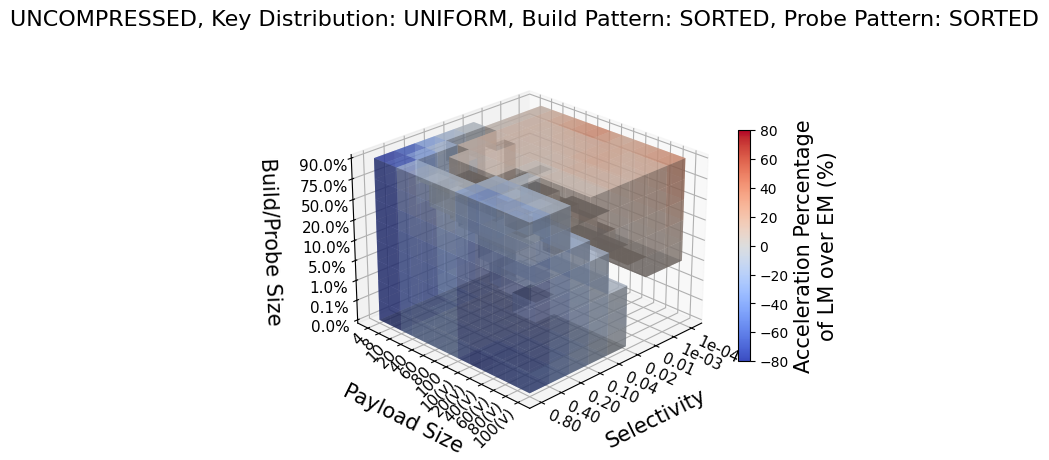

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, ListedColormap
from mpl_toolkits.mplot3d import Axes3D

# 准备数据
selectivities = np.sort(filtered_df['selectivity'].unique())
payload_sizes = np.sort(filtered_df['payload_size'].unique())
build_sizes = np.sort(filtered_df['build_size'].unique())

payload_sizes = np.array([4,8,10,20,40,60,80,100,11,21,41,61,81,101])

def create_uniform_coords(values):
    return np.linspace(0, 1, len(values))

sel_uniform = create_uniform_coords(selectivities)
payload_uniform = create_uniform_coords(payload_sizes)
build_uniform = create_uniform_coords(build_sizes)

sel_label = []
for item in selectivities:
    sel_label.append(str(item))

pay_label = ["4","8"]
for item in payload_sizes:
    if item%10==0:
        pay_label.append(str(item))
for item in payload_sizes:
    if item%10==1:
        pay_label.append(str(item-1)+ '(v)')     

build_label = []
for item in build_sizes:
    build_label.append(str(item))

X, Y, Z = np.meshgrid(sel_uniform, 
                      payload_uniform, 
                      build_uniform, 
                      indexing='ij')


color_3d = np.full(X.shape, np.nan)


for i, sel in enumerate(selectivities):
    for j, payload in enumerate(payload_sizes):
        for k, build in enumerate(build_sizes):
            time_1 = min_time_df[(min_time_df['selectivity'] == sel) & 
                               (min_time_df['payload_size'] == payload) & 
                               (min_time_df['build_size'] == build)]['time'].min()
            time_0 = filtered_df[(filtered_df['selectivity'] == sel) & 
                               (filtered_df['payload_size'] == payload) & 
                               (filtered_df['build_size'] == build) & 
                               (filtered_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_3d[i,j,k] = (time_0-time_1)/time_0 * 100


def reduce_array(arr):
    return (arr[:-1] + arr[1:]) / 2

sel_reduced = reduce_array(sel_uniform)
payload_reduced = reduce_array(payload_uniform)
build_reduced = reduce_array(build_uniform)
Xr, Yr, Zr = np.meshgrid(sel_reduced, payload_reduced, build_reduced, indexing='ij')

color_reduced = np.full(Xr.shape, np.nan)
for i in range(len(sel_reduced)):
    for j in range(len(payload_reduced)):
        for k in range(len(build_reduced)):
            color_block = color_3d[i:i+2, j:j+2, k:k+2]
            if np.any(~np.isnan(color_block)):
                color_reduced[i,j,k] = np.nanmean(color_block)


coolwarm = cm.get_cmap('coolwarm', 256)
newcolors = coolwarm(np.linspace(0, 1, 256))
alpha = np.linspace(0.1, 0.9, 256)
newcolors[:, -1] = alpha
transparent_cmap = ListedColormap(newcolors)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
threshold = 5
mask = ~np.isnan(color_reduced) & (np.abs(color_reduced) > threshold)

voxel_plot = ax.voxels(X, Y, Z, mask,
                      facecolors=transparent_cmap(Normalize(vmin=-80, vmax=80)(color_reduced)),
                      edgecolor='none',
                      linewidth=0.1,
                      alpha=0.6)
def set_uniform_ticks(axis, values, uniform_coords, label):
    n_ticks = min(5, len(values))  
    n_ticks = len(values)
    tick_indices = np.linspace(0, len(values)-1, n_ticks, dtype=int)
    
    if axis == 'x':
        ax.set_xticks(uniform_coords[tick_indices])
        ax.set_xticklabels([format_tick(values[i], 'x') for i in tick_indices],fontsize=11,rotation=-25,ha='left')
        ax.tick_params(axis='x', which='major', pad=-5)
        ax.set_xlabel('\n' + label, fontsize=15)
    elif axis == 'y':
        ax.set_yticks(uniform_coords[tick_indices])
        ax.set_yticklabels([format_tick(values[i], 'y') for i in tick_indices],rotation=45,fontsize=11,ha='right')
        ax.tick_params(axis='y', which='major', pad=-7)
        ax.set_ylabel('\n' + label, fontsize=15)
    else:  # z-axis
        ax.set_zticks(uniform_coords[tick_indices])
        ax.set_zticklabels([format_tick(values[i], 'z') for i in tick_indices],fontsize=11)
        ax.set_zlabel('\n\n' + label, fontsize=15)

def format_tick(value, axis):
    if axis == 'x':  # selectivity
        return f"{value:.0e}" if value < 0.01 else f"{value:.2f}"
    elif axis == 'y':  # payload size
        return f"{value}"
    else:  # build size
        return f"{value/200000:.1f}%"

set_uniform_ticks('x', selectivities, sel_uniform, 'Selectivity')
set_uniform_ticks('y', pay_label, payload_uniform, 'Payload Size')
set_uniform_ticks('z', build_sizes, build_uniform, 'Build/Probe Size')


norm = Normalize(vmin=-80, vmax=80)
mappable = cm.ScalarMappable(cmap=coolwarm, norm=norm)
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax, orientation='vertical',anchor=(-0.5,0.5),shrink=0.6, aspect=20, pad=0.1)
# cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Acceleration Percentage\nof LM over EM (%)', fontsize=15)


title_parts = [
    f"Key Distribution: {fil_probe_distribution.upper()}",
    f"Build Pattern: {fil_build_key_pattern.upper()}",
    f"Probe Pattern: {fil_probe_key_pattern.upper()}"
]
if fil_build_side_hit_ratio != 1:
    title_parts.append(f"Build Hit Ratio: {fil_build_side_hit_ratio}")
title_prefix = "UNCOMPRESSED" if fil_mode == 1 else "COMPRESSED"
plt.title(f"{title_prefix}, " + ", ".join(title_parts), fontsize=16, pad=20)


ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.savefig(f"paper_figure/micro/summary.pdf",bbox_inches='tight')

plt.show()

## zipfian, clustered (fix build/probe)

In [69]:

columns = [
    "mode", "thread_num", "probe_size", "build_size", "selectivity", "payload_size",
    "probe_distribution", "build_side_hit_ratio", "build_key_pattern", "probe_key_pattern",
    "mat_strat", "queue_thr", "time"
]

data = []

with open('origin_data/microbench/benchmark_time_0210_zip15.txt', 'r') as file:
    for line in file:
        values = line.strip().split()
        values = [int(values[0]), int(values[1]), int(values[2]), int(values[3]), float(values[4]),
                  int(values[5]), values[6], float(values[7]), values[8], values[9], values[10],
                  int(values[11]), float(values[12])]
        data.append(values)

df_zip15 = pd.DataFrame(data, columns=columns)




In [70]:
fil_mode = 1
fil_probe_distribution = 'zipfian'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
build_size = 10000000

In [71]:
filtered_df_zip15 = df_zip15[(df_zip15['mode'] == fil_mode) & 
                (df_zip15['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df_zip15['probe_distribution'] == fil_probe_distribution) & 
                 (df_zip15['build_key_pattern'] == fil_build_key_pattern) & 
                 (df_zip15['probe_key_pattern'] == fil_probe_key_pattern)& 
                (df_zip15['build_size'] == build_size)
]
min_time_df_zip15 = filtered_df_zip15[filtered_df_zip15['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df_zip15)



     build_size  selectivity  payload_size     time
0      10000000       0.0001             4  1201.12
1      10000000       0.0001             8  1236.72
2      10000000       0.0001            10  1309.46
3      10000000       0.0001            11  1238.15
4      10000000       0.0001            20  1253.09
..          ...          ...           ...      ...
121    10000000       0.8000            61  4053.11
122    10000000       0.8000            80  4465.26
123    10000000       0.8000            81  4543.43
124    10000000       0.8000           100  4898.89
125    10000000       0.8000           101  4904.65

[126 rows x 4 columns]


In [73]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
build_size = 10000000
filtered_df3 = df[(df['mode'] == fil_mode) & 
                (df['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)& 
                (df['build_size'] == build_size)
]

min_time_df3 = filtered_df3[filtered_df3['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df3)



     build_size  selectivity  payload_size     time
0      10000000       0.0001             4  1292.73
1      10000000       0.0001             8  1399.19
2      10000000       0.0001            10  1555.88
3      10000000       0.0001            11  1534.05
4      10000000       0.0001            20  1759.70
..          ...          ...           ...      ...
121    10000000       0.8000            61  7001.56
122    10000000       0.8000            80  6710.07
123    10000000       0.8000            81  7688.61
124    10000000       0.8000           100  7198.78
125    10000000       0.8000           101  8093.45

[126 rows x 4 columns]


In [74]:
fil_mode = 1
fil_probe_distribution = 'zipfian'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
build_size = 10000000

In [75]:
filtered_df_zip2 = df[(df['mode'] == fil_mode) & 
                (df['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)& 
                (df['build_size'] == build_size)
]
min_time_df_zip2 = filtered_df_zip2[filtered_df_zip2['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df_zip2)



     build_size  selectivity  payload_size     time
0      10000000       0.0001             4  1229.94
1      10000000       0.0001             8  1226.68
2      10000000       0.0001            10  1237.20
3      10000000       0.0001            11  1240.41
4      10000000       0.0001            20  1237.89
..          ...          ...           ...      ...
121    10000000       0.8000            61  4291.63
122    10000000       0.8000            80  4586.63
123    10000000       0.8000            81  4713.88
124    10000000       0.8000           100  4889.39
125    10000000       0.8000           101  5088.70

[126 rows x 4 columns]


In [76]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_key_pattern = 'clustered'
fil_probe_key_pattern = 'random'
build_size = 10000000

In [77]:
filtered_df_cluster = df[(df['mode'] == fil_mode) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)& 
                (df['build_size'] == build_size)
]
min_time_df_cluster = filtered_df_cluster[filtered_df_cluster['mat_strat'] == "1"].groupby(['build_side_hit_ratio','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df_cluster)

build_hit_ratios = filtered_df_cluster['build_side_hit_ratio'].unique()
build_hit_ratios = [0.8,0.4,0.1]

     build_side_hit_ratio  selectivity  payload_size     time
0                     0.1       0.0001             4  1209.61
1                     0.1       0.0001             8  1210.85
2                     0.1       0.0001            10  1245.96
3                     0.1       0.0001            11  1252.87
4                     0.1       0.0001            20  1269.60
..                    ...          ...           ...      ...
499                   0.8       0.8000            61  6701.47
500                   0.8       0.8000            80  6258.63
501                   0.8       0.8000            81  7193.62
502                   0.8       0.8000           100  6818.67
503                   0.8       0.8000           101  7742.98

[504 rows x 4 columns]


# Main Figure Microbenchmark (Figure 9)

/tmp/ipykernel_2943377/366772134.py:263: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


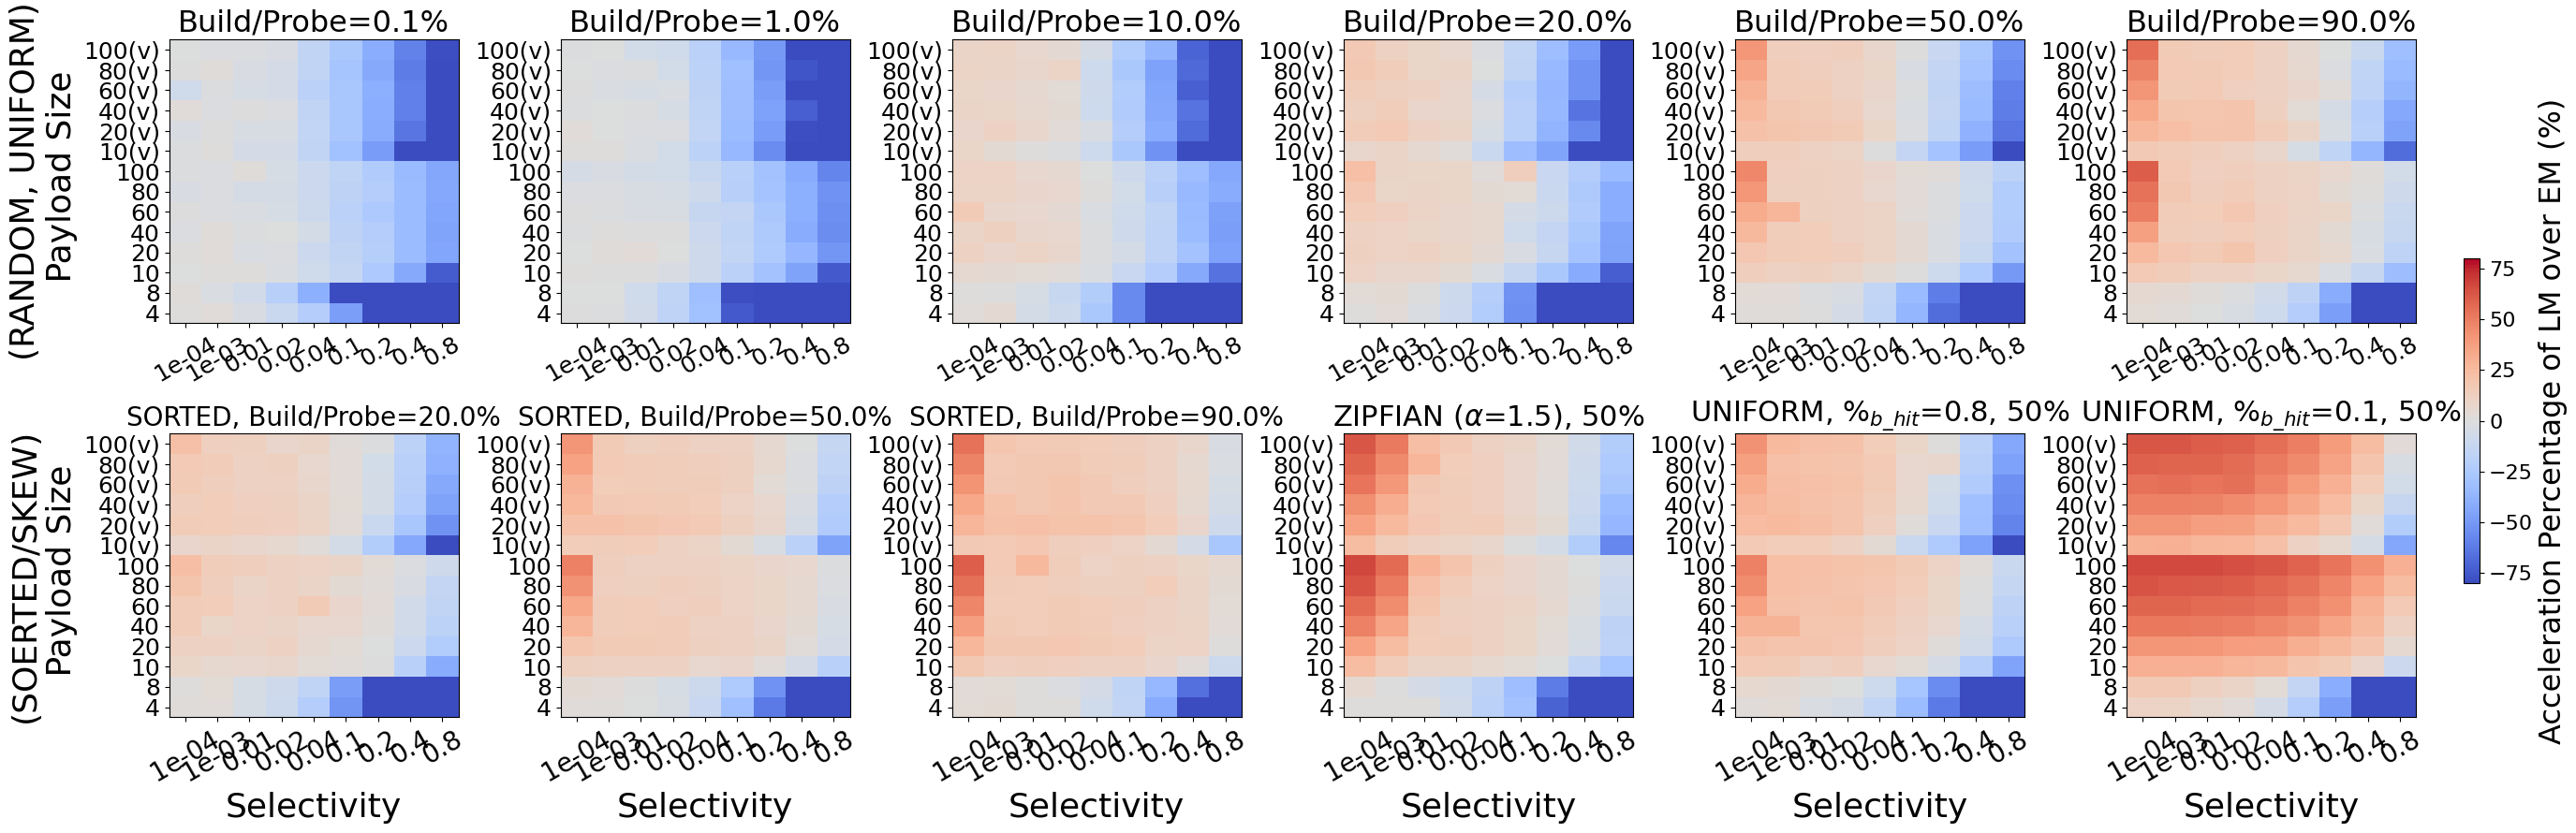

In [80]:

num_plots = 12
num_cols = 6
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(26, 4.5 * num_rows))

build_size_groups = [20000,200000,2000000,4000000,10000000,18000000]
for idx, build_size in enumerate(build_size_groups):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df[filtered_df['build_size'] == build_size]


    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+"(v)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df[(min_time_df['selectivity'] == selectivity) & 
                                 (min_time_df['payload_size'] == payload_size) & (min_time_df['build_size'] == build_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=18,rotation=30)
    ax.tick_params(axis='y', labelsize=18)

    if col==0:
        ax.set_ylabel('(RANDOM, UNIFORM)\n Payload Size',fontsize=26)
        # ax.set_xticks([])
    if row == (num_plots//num_cols -1):
        ax.set_xlabel('Selectivity',fontsize=26)
    if row == 0 and col==0:
        ax.set_title(f'Build/Probe={build_size/200000}%',fontsize=23)
    else:
        ax.set_title(f'Build/Probe={build_size/200000}%',fontsize=23)

build_size_groups = [4000000,10000000,18000000]
for idx, build_size in enumerate(build_size_groups):
    row = 1
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df2[filtered_df2['build_size'] == build_size]

    # 创建一个 NxM 的格子
    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+"(v)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))
    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df2[(min_time_df2['selectivity'] == selectivity) & 
                                 (min_time_df2['payload_size'] == payload_size) & (min_time_df2['build_size'] == build_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=20,rotation=30)
    ax.tick_params(axis='y', labelsize=18)

    ax.set_xlabel('Selectivity',fontsize=26)
    if col==0:
        ax.set_ylabel('(SOERTED/SKEW)\n Payload Size',fontsize=26)

    ax.set_title(f'SORTED, Build/Probe={build_size/200000}%',fontsize=20)


hit_ratio = [1]
for idx, hit in enumerate(hit_ratio):
    idx = 9
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df_zip15

    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+"(v)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))


    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df_zip15[(min_time_df_zip15['selectivity'] == selectivity) & 
                                 (min_time_df_zip15['payload_size'] == payload_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=20,rotation=30)
    ax.tick_params(axis='y', labelsize=18)

    if col==0:
        ax.set_ylabel('Payload Size',fontsize=26)
    ax.set_xlabel('Selectivity',fontsize=26)
    # if row == (num_plots//num_cols -1):
    #     ax.set_xlabel('Selectivity',fontsize=20)

    ax.set_title(r'ZIPFIAN ($\alpha$=1.5), 50%',fontsize=22)

build_hit_ratios = [0.8,0.1]
for idx, build_hit in enumerate(build_hit_ratios):
    col =(idx+10) % num_cols
    row = (idx+10) // num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df_cluster[filtered_df_cluster['build_side_hit_ratio'] == build_hit]
    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+"(v)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))
    # label = ['1e-4','1e-3','.01','.02','.04','.1','.2','.4','.8']


    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df_cluster[(min_time_df_cluster['selectivity'] == selectivity) & 
                                 (min_time_df_cluster['payload_size'] == payload_size) & (min_time_df_cluster['build_side_hit_ratio'] == build_hit)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=20,rotation=30)
    ax.tick_params(axis='y', labelsize=18)

    ax.set_xlabel('Selectivity',fontsize=26)
    if col==0:
        ax.set_ylabel('Payload Size',fontsize=23)

    ax.set_title(r'UNIFORM, $\%_{b\_hit}$'+f'={build_hit}, 50%',fontsize=22)
    


plt.subplots_adjust(wspace=-0.1, hspace=-0.1) 
cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.1,0.5), shrink=0.5)
# cbar = fig.colorbar(c, ax=axes, orientation='horizontal',anchor=(0.6,9.5), shrink=0.5)
cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=23)

cbar.ax.tick_params(labelsize=16) 

for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'key distribution: {fil_probe_distribution.upper()}'
fig_name =  f'{fil_probe_distribution.upper()}_'

if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
    fig_name+=f'_{fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
    fig_name = 'UNCOMPRESSED_'+fig_name
else:
    title = 'COMPRESSED, '+title
    fig_name = 'COMPRESSED_'+fig_name
fig_name+='total'
title = 'UNIFORM                                                                                                    SORT/SKEW'
# fig.suptitle(title, fontsize=26)
plt.tight_layout()
plt.savefig(f"paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
plt.show()


# Breakdown (different build size)

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


## fixed build size, fix payloads, different selectivity. (Figure 10 (a))

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[-2])
            queue_thr = int(line1[-1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

line_color = ['#90C9E6','#02304A','#219EBC','#FEB705','#FA8600']
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes = [10000000]
    payload_size = 40
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    
    fig = plt.figure(figsize=(8, 4.7))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['payload_size'] ==payload_size)]
        selectivities = df_build['selectivity'].unique()
        selectivities = selectivities[:-1]
        print(selectivities)
        indices = np.arange(len(selectivities))
        indices = 5.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        latencies_4 = []
        for i, selectivity in enumerate(selectivities):
            df_sel = df_build[df_build['selectivity'] == selectivity]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            df_sel_4 = df_sel[df_sel['mat_strat'] == 4].nsmallest(1, 'latency')
            index = i * 5
            if not df_sel_0.empty:
                #late mat(batch)
                plt.bar(index+ bar_width*4, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, label='Others' if i == 0 else "", color = color_map[0],edgecolor='grey')
                plt.bar(index+ bar_width*4, df_sel_0['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='I/O' if i == 0 else "", color = color_map[1],edgecolor='grey')
                plt.bar(index+ bar_width*4, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build' if i == 0 else "", color = color_map[2],edgecolor='grey')
                plt.bar(index+ bar_width*4, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize' if i == 0 else "", color = color_map[3],edgecolor='grey')
                plt.bar(index+ bar_width*4, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                plt.bar(index + bar_width*3, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_3['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index, df_sel_1['others'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index, df_sel_1['io'].values[0], bar_width, bottom=df_sel_1['others'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                plt.bar(index+ bar_width, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index+ bar_width, df_sel_2['io'].values[0], bar_width, bottom=df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0],  color = color_map[1],edgecolor='grey')
                plt.bar(index+ bar_width, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                plt.bar(index+ bar_width, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
            if not df_sel_4.empty:
                #late mat(batch)
                # if abs(df_sel_4['io'].values[0]+df_sel_4['others'].values[0]+df_sel_4['hash_build_time'].values[0]+df_sel_4['materialize_time'].values[0]+ df_sel_4['map_build_time'].values[0] - df_sel_4['latency'].values[0])<0.2:
                plt.bar(index + bar_width*2, df_sel_4['others'].values[0], bar_width,  color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['io'].values[0], bar_width, bottom=df_sel_4['others'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['hash_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_4['others'].values[0], color = color_map[2],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['materialize_time'].values[0] , bar_width, bottom=df_sel_4['io'].values[0] + df_sel_4['others'].values[0] + df_sel_4['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['map_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_4['others'].values[0] + df_sel_4['hash_build_time'].values[0]+ df_sel_4['materialize_time'].values[0],  color = color_map[4],edgecolor='grey')
                latencies_4.append(df_sel_4['latency'].values[0])

        top = 300
        plt.scatter(indices, np.array(latencies_1)+top, marker='v',linewidth=2.3,color=line_color[0], label='EM')
        plt.plot(indices+ bar_width, np.array(latencies_2)+top, marker='o',markeredgewidth=2,ms=8,linewidth=0, color=line_color[1], label='LM (naive)')
        plt.plot(indices+ bar_width*2, np.array(latencies_4)+top, marker='*',markeredgewidth=2,ms=9,linewidth=0, color=line_color[2], label='LM (sort)')
        plt.plot(indices+ bar_width*3, np.array(latencies_3)+top, marker='s',markeredgewidth=2,ms=7,linewidth=0, color=line_color[3], label='LM (unique)')
        plt.plot(indices + bar_width*4, np.array(latencies_0)+top, marker='^',markeredgewidth=2,ms=7.5,linewidth=0, color=line_color[4], label='LM (batch)')
        plt.xlabel('Selectivity',fontsize=20)
        plt.ylabel('Latency (ms)',fontsize=20)
        plt.title(f'Build/Probe: {build_size/200000}% Payload_size: {payload_size}',fontsize=17)
        plt.xticks([i * 5 + 1.5*bar_width for i in range(len(selectivities))],selectivities,fontsize=17)
        plt.yticks(fontsize=15)
        plt.xlim(-bar_width, len(selectivities)*5- 1 )

        # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
        plt.legend(fontsize=17, ncol=2)
    fig_name = 'different_sel'
    plt.tight_layout()
    plt.savefig(f"paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



[1.e-04 1.e-03 1.e-02 2.e-02 4.e-02 1.e-01 2.e-01 4.e-01]


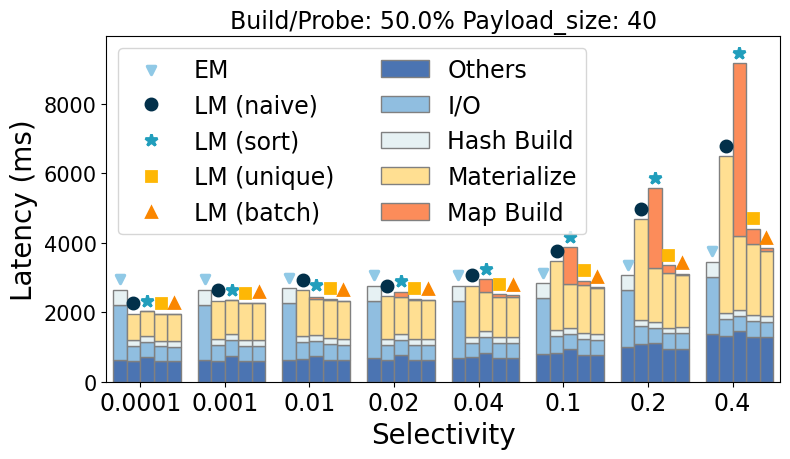

,mat_strat,queue_thr,build_size,selectivity,payload_size,map_build_time,materialize_time,hash_build_time,others,io,latency
0,3,100,2000000,0.0001,4,0.26,22.34,35.38,475.28,350.27,860.93
1,3,1000,2000000,0.0001,4,0.90,20.77,34.89,464.14,291.68,790.72
2,3,2000,2000000,0.0001,4,0.58,23.73,35.31,475.94,329.84,841.09
3,3,100,2000000,0.0001,8,0.25,44.11,34.47,492.00,317.68,844.16
4,3,1000,2000000,0.0001,8,0.58,42.92,35.80,501.00,290.85,827.65
...,...,...,...,...,...,...,...,...,...,...,...
19,4,20000,2000000,0.0400,20,275.95,205.14,36.55,757.89,240.42,1515.96
20,4,20000,4000000,0.0400,20,276.38,293.00,69.62,821.71,304.67,1765.38
21,4,20000,10000000,0.0400,20,310.49,625.73,173.74,822.28,430.70,2503.38
22,4,20000,15000000,0.0400,20,313.42,862.22,256.87,1130.22,502.30,3065.03


In [89]:
# Example usage
file_path = 'origin_data/microbench/breakdown_0115.txt'  # Replace with your file path
df_batch = parse_file(file_path)
file_path = 'origin_data/microbench/breakdown_0115_unique.txt'  # Replace with your file path
df = parse_file(file_path)

file_path = 'origin_data/microbench/benchmark_sort_0206.log'  # Replace with your file path
df_sort = parse_file_multi(file_path)

df_total = pd.concat([df, df_batch,df_sort],axis=0)
plot_data(df_total)
df_total

## breakdown skew + unique (fix sel, payload size, build size) (Figure 10(b))

In [90]:
def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            skew = float(line1[5])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, skew, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'skew', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def parse_file_single(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            skew = 0
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, skew, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'skew', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
line_color = ['#90C9E6','#02304A','#FEB705','#FA8600']

def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes = [10000000]
    selectivity = 0.04
    payload_size = 10
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    skews= [0,1,1.5,0.8,0.1]
    rchar = ['435M','435M','406M', '302M']
    fig = plt.figure(figsize=(5.7, 3.9))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['selectivity'] ==selectivity) & (df['payload_size'] ==payload_size)]
        skews= [0,1.5,0.8,0.1]
        indices = np.arange(len(skews))
        indices = 4.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        labels = ['uniform','zipfian','cluster\n(0.8)','cluster\n(0.4)','cluster\n(0.2)','cluster\n(0.1)']
        labels = ['uniform','zipfian\n(1.5)','cluster\n(0.8)','cluster\n(0.1)']    
        for i, skew in enumerate(skews):
            df_sel = df_build[df_build['skew'] == skew]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            index = i * 4
            if not df_sel_0.empty:
                #late mat(batch)
                print(df_sel_0['materialize_time'].values[0])
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index+ bar_width*3, df_sel_0['others'].values[0], bar_width, label='Others' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0], label='IO' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width*3, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, label='Others' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['io'].values[0], bar_width, bottom= df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='IO' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                if abs(df_sel_3['io'].values[0]+df_sel_3['others'].values[0]+df_sel_3['hash_build_time'].values[0]+df_sel_3['materialize_time'].values[0]+ df_sel_3['map_build_time'].values[0] - df_sel_3['latency'].values[0])<1:
                    plt.bar(index + bar_width*2, df_sel_3['others'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_0['io'].values[0], bar_width, bottom=df_sel_3['others'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]+df_sel_3['map_build_time'].values[0])
                else:
                    plt.bar(index + bar_width*2, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_3['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index , df_sel_1['others'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index, df_sel_1['io'].values[0], bar_width, bottom=df_sel_1['others'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                if abs(df_sel_2['io'].values[0]+df_sel_2['others'].values[0]+df_sel_2['hash_build_time'].values[0]+df_sel_2['materialize_time'].values[0]+ df_sel_2['map_build_time'].values[0]-df_sel_2['latency'].values[0])<1:
                    plt.bar(index+ bar_width, df_sel_2['others'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['io'].values[0], bar_width, bottom=df_sel_2['others'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]+ df_sel_2['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['io'].values[0], bar_width, bottom=df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0],  color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        top =100
        plt.plot(indices, np.array(latencies_1)+top, marker='v', markeredgewidth=2,ms=7,linewidth=0,color=line_color[0], label='EM')
        plt.plot(indices+ bar_width, np.array(latencies_2)+top, marker='o',markeredgewidth=2,ms=8,linewidth=0, color=line_color[1], label='LM (naive)')
        plt.plot(indices+ bar_width*2, np.array(latencies_3)+top, marker='s',markeredgewidth=2,ms=7,linewidth=0, color=line_color[2], label='LM (unique)')
        plt.plot(indices + bar_width*3, np.array(latencies_0)+top, marker='^',markeredgewidth=2,ms=7,linewidth=0, color=line_color[3], label='LM (batch)')
        plt.xlabel('Skew distribution',fontsize=17)
        plt.ylabel('Latency (ms)',fontsize=17)
        plt.title(f'Build/Probe: {build_size/200000}% Selectivity: {selectivity}, Payload: {payload_size}B',fontsize=16)
        plt.xticks([i * 4 + 1.5*bar_width for i in range(len(skews))],labels,fontsize=16)
        plt.yticks(fontsize=13)

        for i in range(len(skews)):
            plt.text(i * 4 + 1*bar_width , 2070, rchar[i]+'B', fontsize = 16)
            

        # plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left',fontsize=13)
        plt.ylim([0,2300])
        # plt.legend(fontsize=11.5)
    fig_name = 'skew_breakdown'
    plt.tight_layout()
    plt.savefig(f"paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()


428.11
400.82
374.41
100.25


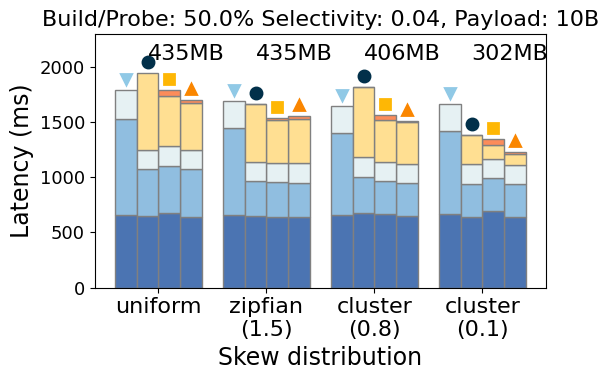

In [92]:
file_path = 'origin_data/microbench/breakdown_skew.txt'  # Replace with your file path
df_batch = parse_file_multi(file_path)
file_path = 'origin_data/microbench/breakdown_0204.txt'  # Replace with your file path
df = parse_file_single(file_path)
df = df[df['build_size']==10000000]
file_path = 'origin_data/microbench/breakdown_zip15_0210.txt'  # Replace with your file path
df_zip = parse_file_multi(file_path)

df_total = pd.concat([df, df_batch,df_zip],axis=0)
plot_data(df_total)




## Multi column (Figure 10(d))

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            column_num = int(line1[5])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, column_num, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'column_num', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def parse_file_single(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            column_num = 1
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, column_num, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'column_num', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes = [10000000]
    selectivity = 0.1
    payload_size = 10
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    
    fig = plt.figure(figsize=(7, 5))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['selectivity'] ==selectivity) & (df['payload_size'] ==payload_size)]
        column_number = [1,2,4,6,8,10]
        indices = np.arange(len(column_number))
        indices = 2.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        enh = []
        for i, cols in enumerate(column_number):
            df_sel = df_build[df_build['column_num'] == cols]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[(df_sel['mat_strat'] == 1) &(df_sel['queue_thr'] == 1000)]
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            # df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            index = i * 2
            enh.append( (df_sel_1['latency'].values[0] - df_sel_0['latency'].values[0])/df_sel_1['latency'].values[0] *100.0)
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index+ bar_width, df_sel_0['others'].values[0], bar_width, label='Others' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0], label='I/O' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index , df_sel_1['others'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index , df_sel_1['io'].values[0], bar_width, bottom=df_sel_1['others'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index , df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
        top =200
        plt.plot(indices, np.array(latencies_1)+top, marker='v', markeredgewidth=2,ms=7,linewidth=0,color=line_color[0], label='EM')
        # plt.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o',markeredgewidth=2,ms=8,linewidth=2.3, color=line_color[1], label='Late materialize (unique)')
        # plt.plot(indices+ bar_width, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='LM (naive)')
        plt.plot(indices+bar_width, np.array(latencies_0)+top, marker='^',markeredgewidth=2,ms=7,linewidth=0, color=line_color[2], label='LM (batch)')
        for i in range(len(column_number)):
            plt.text(i * 2+0.3*bar_width  , latencies_0[i]+300, '%.1f'%enh[i]+'%', fontsize = 21) 
        plt.xlabel('Number of columns',fontsize=20)
        plt.ylabel('Latency (ms)',fontsize=20)
        plt.title(f'Build/Probe: {build_size/200000}% Sel: {selectivity}, Payload size: {payload_size}',fontsize=20)
        plt.xticks([i * 2 + 1*bar_width for i in range(len(column_number))],column_number,fontsize=19)
        plt.yticks(fontsize=13)
        plt.ylim([0,8000])


        # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
        plt.legend(fontsize=15,ncol=1)
    fig_name = 'multi_column_breakdown'
    plt.tight_layout()
    plt.savefig(f"paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



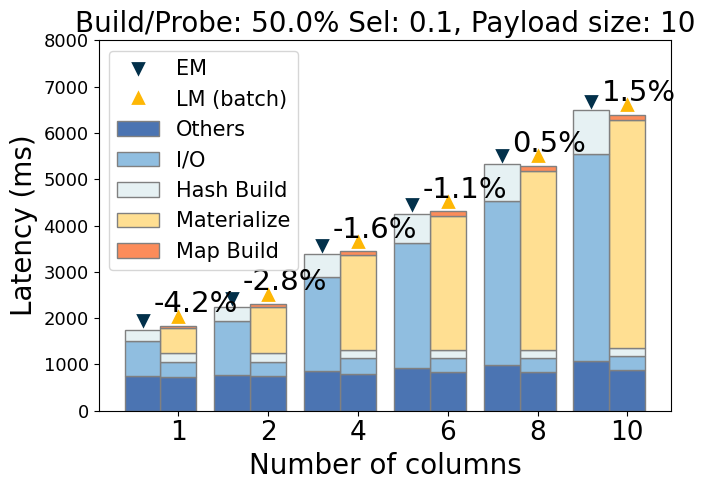

In [96]:
# Example usage
file_path = 'origin_data/microbench/breakdown_0204_multicol.txt'  # Replace with your file path
df_batch = parse_file_multi(file_path)
file_path = 'origin_data/microbench/breakdown_0204.txt'  # Replace with your file path
df = parse_file_single(file_path)
file_path = 'origin_data/microbench/breakdown_0215_multicol.txt'  # Replace with your file path
df_batch_2 = parse_file_multi(file_path)
df = df[df['build_size']==10000000]

df_total = pd.concat([df, df_batch_2],axis=0)
plot_data(df_total)

In [102]:
file_path = 'origin_data/microbench/breakdown_0215_multicol.txt'  # Replace with your file path
df_batch_2 = parse_file_multi(file_path)
df_batch_1 = df_batch[df_batch['selectivity']!=0.001].reset_index()
df_avg = (df_batch_1+df_batch_2)/2
df_avg = df_avg.round().astype(df_batch_2.dtypes.to_dict())
df_total = pd.concat([df, df_batch_2],axis=0)

In [103]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
fil_build_size = 10000000

In [104]:
filtered_df = df_total

min_time_df = filtered_df[filtered_df['mat_strat'] == 1].groupby(['build_size','selectivity', 'payload_size','column_num'])["latency"].min().reset_index()
selectivities = [0.01,0.02,0.04,0.1]
selectivities = [0.1]
min_time_df

,build_size,selectivity,payload_size,column_num,latency
0,10000000,0.0001,4,1,1268.23
1,10000000,0.0001,8,1,1378.67
2,10000000,0.0001,10,1,1518.56
3,10000000,0.0001,11,1,1489.70
4,10000000,0.0001,20,1,1710.23
...,...,...,...,...,...
281,10000000,0.8000,61,1,6825.11
282,10000000,0.8000,80,1,7476.43
283,10000000,0.8000,81,1,7462.27
284,10000000,0.8000,100,1,7398.43


## Multi col Heatmap (Figure 10(c))

1


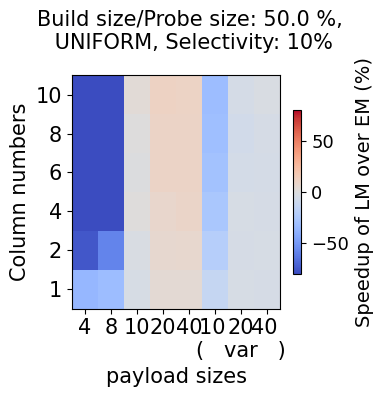

In [106]:

# 创建一个包含多个子图的图形，排成三列
num_plots = len(selectivities)
print(num_plots)
num_cols = 1
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(3.9, 4 * num_rows))


for idx, selectivity in enumerate(selectivities):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes
    # ax = axes[row]
    # only fixed length string 
    group_df = filtered_df[filtered_df['selectivity'] == selectivity]
    payload_sizes = group_df['payload_size'].unique()
    payload_sizes = [4,8,10,20,40,11,21,41]
    column_nums = group_df['column_num'].unique()
    selectivities.sort()
    column_nums.sort()

    label = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size%10==1:
            if payload_size==21:
                label.append(str(payload_size//10 * 10)+'\n(   var   )')
            else:
                label.append(str(payload_size//10 * 10)+' ')
        else:
            label.append(str(payload_size))

    column_str = []
    for i, column_num in enumerate(column_nums):
        column_str.append(str(column_num))

    color_matrix = np.zeros((len(column_nums), len(payload_sizes)))

    for i, column_num in enumerate(column_nums):
        for j, payload_size in enumerate(payload_sizes):
            time_1 = min_time_df[(min_time_df['payload_size'] == payload_size) & 
                                 (min_time_df['column_num'] == column_num) & (min_time_df['selectivity'] == selectivity)]['latency'].min()
            time_0 = group_df[(group_df['payload_size'] == payload_size) & 
                              (group_df['column_num'] == column_num) & 
                              (group_df['mat_strat'] == 0)]['latency'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
        

    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, column_str, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    if col==0:
        ax.set_ylabel('Column numbers',fontsize=15)
    if row == (num_plots//num_cols -1):
        ax.set_xlabel('payload sizes',fontsize=15)

    # ax.set_title(f'Selectivity: {selectivity*100.0}%',fontsize=18)



cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(0,0.5), shrink=0.7)
cbar.ax.tick_params(labelsize=13) 
cbar.set_label('Speedup of LM over EM (%)',fontsize=14)

for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'Build size/Probe size: {fil_build_size/200000} %,\n {fil_probe_distribution.upper()}, Selectivity: 10%'
if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'

fig.suptitle(title, fontsize=15)
fig_name = 'multi_column_heatmap_short'
plt.tight_layout()
plt.savefig(f"paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
plt.show()


## compressed storage (Figure 12)

In [107]:
def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            data_name = (line1[5])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, data_name, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'data_name', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


In [109]:
def plot_data(df):
    line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = [10000000]
    payload_size = 20
    selectivity = 0.02
    num_plots = 1
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    # fig, axes = plt.subplots(num_cols,num_rows,figsize=(14, 10))
    fig = plt.figure(figsize=(10, 5.1))
    thre = 8000
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        df_build = df[(df['build_size'] == build_size)& (df['selectivity'] == selectivity)]
   
        data_names = ['movieid','house_price','books_200M_uint64','genome_200M_uint64','japanese','ps_comment','email','uuid','yago','urls' ]
        data_names_label = ['movieid\nint32\n(50%)','  houseprice\nint32\n(33%)','books\nint64\n(50%)','genome\nint64\n(38%)','japanese\nstring\n(13%)','  comment\nstring\n(31%)','email\nstring\n(42%)','uuid\nstring\n(42%)','yago\nstring\n(56%)','urls\nstring\n(44%)' ]
        data_names_label = ['movieid\nint32\n(50%)\n bitpack','    houseprice\nint32\n(33%)\n RLE','    books\nint64\n(50%)\n bitpack','genome\nint64\n(38%)\n bitpack','japanese\nstring\n(13%)\n FSST','  comment\nstring\n(31%)\n FSST','email\nstring\n(42%)\n FSST','uuid\nstring\n(42%)\n FSST','yago\nstring\n(56%)\n FSST','urls\nstring\n(44%)\n FSST' ]
        
        indices = np.arange(len(data_names))
        indices = 3.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        enh = []
        for i, data_name in enumerate(data_names):
            df_sel = df_build[df_build['data_name'] == data_name]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            enh.append((df_sel_1['latency'].values[0]-df_sel_0['latency'].values[0])/df_sel_1['latency'].values[0] * 100.0)
            index = i * 3
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index+ bar_width*2, df_sel_0['others'].values[0], bar_width, label='Others' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0], label='I/O' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build' if i == 0 else "", color = color_map[4],edgecolor='grey')
 
                else:
                    plt.bar(index+ bar_width*2, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['io'].values[0], bottom=df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                    
                latencies_0.append(df_sel_0['latency'].values[0])
                if df_sel_0['latency'].values[0]>thre:
                    plt.text(index-bar_width, thre*0.95, str(int(df_sel_0['latency'].values[0])), fontsize=15)
            if not df_sel_3.empty:
                #late mat(batch)
                if abs(df_sel_3['io'].values[0]+df_sel_3['others'].values[0]+df_sel_3['hash_build_time'].values[0]+df_sel_3['materialize_time'].values[0]+ df_sel_3['map_build_time'].values[0] - df_sel_3['latency'].values[0])<1:
                    plt.bar(index + bar_width, df_sel_0['others'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]+df_sel_3['map_build_time'].values[0])
                else:
                    plt.bar(index + bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, bottom=df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
                if df_sel_3['latency'].values[0]>thre:
                    plt.text(index, thre*0.95, str(int(df_sel_3['latency'].values[0])),fontsize=14)
            if not df_sel_1.empty:
                # early
                plt.bar(index, df_sel_1['others'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index, df_sel_1['io'].values[0], bar_width, bottom=df_sel_1['others'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
        top = 200
        plt.plot(indices, np.array(latencies_1)+top, marker='v', markeredgewidth=2,ms=7,linewidth=0,color=line_color[0], label='EM')
        plt.plot(indices+ bar_width, np.array(latencies_3)+top, marker='o',markeredgewidth=2,ms=8,linewidth=0, color=line_color[1], label='LM(batch wo full \ndecompression)')
        # plt.plot(indices+ bar_width*2, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='LM (naive)')
        plt.plot(indices + bar_width*2, np.array(latencies_0)+top, marker='^',markeredgewidth=2,ms=7,linewidth=0, color=line_color[2], label='LM (batch)')
        plt.xlabel('Datasets',fontsize=19)
        plt.ylabel('Latency (ms)',fontsize=19)
        plt.title(f'Build/Probe: {build_size/200000}% Selectivity:{selectivity} Compressed Real-world Datasets',fontsize=17)
        plt.xticks([i * 3 + bar_width for i in range(len(data_names))],data_names_label,fontsize=14)
        plt.yticks(fontsize=14)
        plt.ylim([0,thre])
        plt.xlim(-bar_width, len(data_names)*3- 0.2 )
        for i in range(len(data_names)):
            plt.text(i * 3+bar_width  , latencies_0[i]+600, '%.1f'%enh[i]+'%', fontsize = 17) 


    # plt.legend(bbox_to_anchor=(1.0, 0.9), loc='upper left',fontsize=12)

    # plt.legend(fontsize=11.5, bbox_to_anchor=(0.5, 0.26))
    plt.legend(fontsize=16,ncol=3,frameon=False)
    fig_name = 'compressed_breakdown'
    plt.tight_layout()
    plt.savefig(f"paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



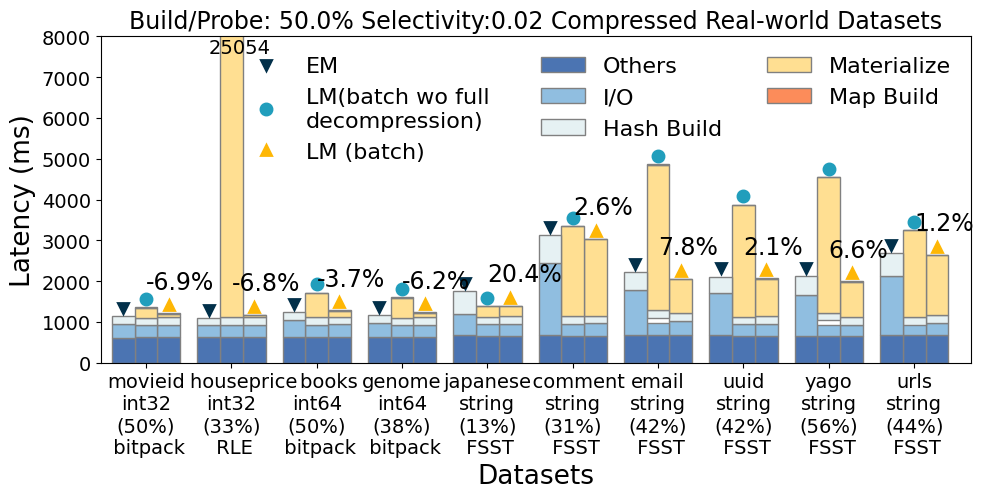

In [111]:

file_path = 'origin_data/microbench/breakdown_compress_real_0204_new.txt'  # Replace with your file path
df_batch = parse_file_multi(file_path)
file_path = 'origin_data/microbench/breakdown_compress_real_0204_no_full.txt'  # Replace with your file path
df = parse_file_multi(file_path)
df_total = pd.concat([df, df_batch],axis=0)
plot_data(df_total)


## Multi thread (Appendix)

In [112]:
def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            thread_num = int(line1[5])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, thread_num, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'thread_num', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def plot_data(df):
    line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = [10000000]
    payload_size = 20
    selectivity = 0.1
    num_plots = 1
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    # fig, axes = plt.subplots(num_cols,num_rows,figsize=(14, 10))
    fig = plt.figure(figsize=(6, 3))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        df_build = df[(df['build_size'] == build_size)& (df['selectivity'] == selectivity)& (df['payload_size'] == payload_size)]
   
        thread_numbers = [1,2,4,8,16]
        indices = np.arange(len(thread_numbers))
        indices = 2.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        enh1 = []
        enh2 = []
        base1 = df_build[(df_build['thread_num'] == 1) & (df_build['mat_strat'] == 0)]['latency'].values[0]

        base2 = df_build[(df_build['thread_num'] == 1) & (df_build['mat_strat'] == 1)].nsmallest(1, 'latency')['latency'].values[0]
        for i, thread in enumerate(thread_numbers):
            df_sel = df_build[df_build['thread_num'] == thread]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            # df_sel_0 = df_sel[(df_sel['mat_strat'] == 1)&(df_sel['queue_thr'] == 100)]
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            enh2.append(base2/df_sel_0['latency'].values[0])
            enh1.append(base1/df_sel_1['latency'].values[0])
            index = i * 2
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index+ bar_width, df_sel_0['io'].values[0], bar_width, label='I/O' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index , df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])

        top = 100
        plt.plot(indices, np.array(latencies_1)+top, marker='v', markeredgewidth=2,ms=7,linewidth=0,color=line_color[0], label='EM')
        # plt.plot(indices+ bar_width, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='LM (naive)')
        plt.plot(indices + bar_width, np.array(latencies_0)+top, marker='^',markeredgewidth=2,ms=7,linewidth=0, color=line_color[2], label='LM (batch)')
        plt.xlabel('Thread Number',fontsize=15)
        plt.ylabel('Latency (ms)',fontsize=15)
        plt.title(f'Build/Probe: {build_size/200000}% Selectivity: {selectivity} Payload_size: {payload_size}',fontsize=14)
        plt.xticks([i * 2 + 0.5*bar_width for i in range(len(thread_numbers))],thread_numbers,fontsize=13)
        for i in range(1,len(thread_numbers)):
            plt.text(i * 2-0.5*bar_width  , latencies_1[i]+200, '%.1f'%(enh1[i])+'x', fontsize = 14) 
            plt.text(i * 2+0.7*bar_width  , latencies_0[i]+170, '%.1f'%(enh2[i])+'x', fontsize = 14) 




    # plt.legend(bbox_to_anchor=(1.0, 0.9), loc='upper left',fontsize=10)
    # plt.tight_layout()
    plt.legend(fontsize=11,  ncol=2, frameon=False)
    fig_name = 'multithread_breakdown'
    plt.tight_layout()
    plt.savefig(f"paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



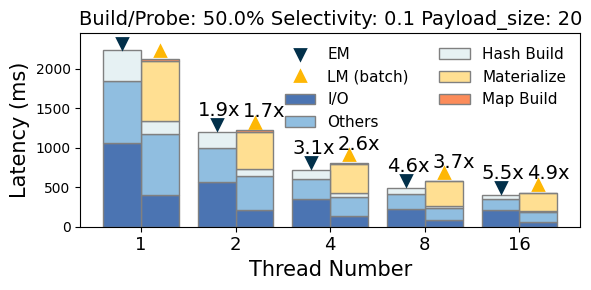

In [115]:
file_path = 'origin_data/microbench/breakdown_0206_multithread.txt'  # Replace with your file path
df = parse_file_multi(file_path)

plot_data(df)


## OOM (Figure 11)

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def parse_file(file_path):
    # Define column names
    columns = ["probe_size", "mem_lim", "thread_num", "mode", "probe_side", "build_side", "sel", "payload", "dist", "hit_ratio", "build_dist", "probe_dist", "mat_strat", "queue_thr", "latency", "read_bytes", "rchar"]
    
    # Read file and create DataFrame
    df = pd.read_csv(file_path, delim_whitespace=True, header=None, names=columns)
    
    # Convert mem_lim column to float (remove GB suffix)
    df["mem_lim"] = df["mem_lim"].str.replace("GB", "").astype(float)
    
    return df

def filter_and_plot(df):
    line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
    color_map = ['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    
    # Filter data for mat_strat=1 and find rows with minimum latency and rchar
    df_mat_strat_1 = df[df["mat_strat"] == 1]
    df_min_latency = df_mat_strat_1.loc[df_mat_strat_1.groupby("mem_lim")["latency"].idxmin()]
    df_min_rchar = df_mat_strat_1.loc[df_mat_strat_1.groupby("mem_lim")["rchar"].idxmin()]

    # Filter data for mat_strat=0
    df_mat_strat_0 = df[df["mat_strat"] == 0]

    # Create subplots
    mem_lims = sorted(df["mem_lim"].unique())
    bar_width = 0.4
    index = range(len(mem_lims))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    fig.suptitle('Build/Probe: 50.0%, Selectivity: 0.1, Payload_size: 20', fontsize=17, y=0.9)

    # Plot latency for mat_strat=0 and mat_strat=1
    latency_0 = [df_mat_strat_0[df_mat_strat_0["mem_lim"] == mem_lim]["latency"].values[0] for mem_lim in mem_lims]
    latency_1 = [df_min_latency[df_min_latency["mem_lim"] == mem_lim]["latency"].values[0] if mem_lim in df_min_latency["mem_lim"].values else 0 for mem_lim in mem_lims]
    
    ax1.bar(index, latency_0, bar_width, label='Early Materialize', color=color_map[1])
    ax1.bar([i + bar_width for i in index], latency_1, bar_width, label='Late Materialize (batch)', color=color_map[3])
    ax1.plot(index, np.array(latency_0) * 1.01, marker='v', markeredgewidth=2, ms=7, linewidth=2.3, color=line_color[1])
    ax1.plot([i + bar_width for i in index], np.array(latency_1) * 1.01, marker='^', markeredgewidth=2, ms=8, linewidth=2.3, color=line_color[2])
    
    ax1.set_xlabel('Memory Limit (GB)', fontsize=14)
    ax1.set_ylabel('Latency (ms)', fontsize=14)
    ax1.set_xticks([i + bar_width / 2 for i in index])
    ax1.set_xticklabels([str(round(mem, 1)) for mem in mem_lims], fontsize=12)
    # ax1.legend(fontsize=10)

    # Plot IO amount (rchar) for mat_strat=0 and mat_strat=1
    io_0 = [df_mat_strat_0[df_mat_strat_0["mem_lim"] == mem_lim]["rchar"].values[0] for mem_lim in mem_lims]
    io_1 = [df_min_rchar[df_min_rchar["mem_lim"] == mem_lim]["rchar"].values[0] if mem_lim in df_min_rchar["mem_lim"].values else 0 for mem_lim in mem_lims]
    
    ax2.bar(index, io_0, bar_width, label='EM', color=color_map[1])
    ax2.bar([i + bar_width for i in index], io_1, bar_width, label='LM (batch)', color=color_map[3])
    ax2.plot(index, np.array(io_0) * 1.01, marker='v', markeredgewidth=2, ms=7, linewidth=2.3, color=line_color[1])
    ax2.plot([i + bar_width for i in index], np.array(io_1) * 1.01, marker='^', markeredgewidth=2, ms=8, linewidth=2.3, color=line_color[2])
    
    ax2.set_xlabel('Memory Limit (GB)', fontsize=14)
    ax2.set_ylabel('IO Amount (Byte)', fontsize=14)
    ax2.set_xticks([i + bar_width / 2 for i in index])
    ax2.set_xticklabels([str(round(mem, 1)) for mem in mem_lims], fontsize=12)
    ax2.legend(fontsize=14)

    # Save and display the figure
    plt.tight_layout()
    plt.savefig("paper_figure/micro/combined_OOM_plot.pdf", bbox_inches='tight')
    plt.show()

# Example usage


/tmp/ipykernel_2943377/1070531960.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None, names=columns)


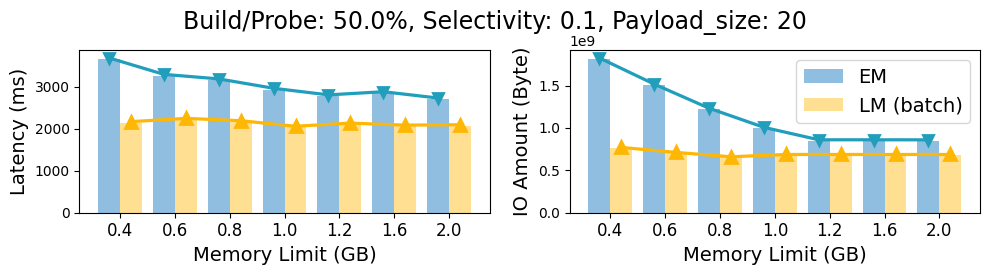

In [118]:
file_path = 'origin_data/microbench/benchmark_oom_0206.txt'  # Replace with your file path
df = parse_file(file_path)
filter_and_plot(df)

## Mid pipeline (Figure 14)

In [121]:
import pandas as pd


columns = [
    "result_size", "thread_num", "probe_size", "build_size1", "build_size2",
    "sel1", "sel2", "payload", "mat_strat", "queue_thr", "add_breaker", "latency"
]


file_path = "origin_data/microbench/mid_case2.txt"
data = pd.read_csv(file_path, sep=" ", header=None, names=columns)

filtered_data = data[data["result_size"] != 0]


grouped_data_case2 = filtered_data.groupby(["sel1", "sel2", "payload", "mat_strat","add_breaker"], as_index=False).apply(
    lambda group: group.loc[group["latency"].idxmin()]
)

grouped_data_case2

/tmp/ipykernel_2943377/1471462821.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_data_case2 = filtered_data.groupby(["sel1", "sel2", "payload", "mat_strat","add_breaker"], as_index=False).apply(


,result_size,thread_num,probe_size,build_size1,build_size2,sel1,sel2,payload,mat_strat,queue_thr,add_breaker,latency
0,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,0.0,0.0,0.0,1472.78
1,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,0.0,0.0,1.0,1502.41
2,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,1.0,1000.0,0.0,1452.07
3,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,1.0,1000.0,1.0,1454.00
4,20000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0010,10.0,0.0,0.0,0.0,1528.73
...,...,...,...,...,...,...,...,...,...,...,...,...
319,8000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.4000,10.0,1.0,100.0,1.0,3732.70
320,16000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.8000,10.0,0.0,0.0,0.0,2179.94
321,16000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.8000,10.0,0.0,0.0,1.0,2248.77
322,16000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.8000,10.0,1.0,1000.0,0.0,3650.21


In [134]:
import pandas as pd


columns = [
     "result_size", "thread_num", "probe_size", "build_size1", "build_size2",
    "sel1", "sel2", "payload", "mat_strat", "queue_thr", "mid_pipe", "latency"
]


file_path = "origin_data/microbench/mid_case1.txt"
data = pd.read_csv(file_path, sep=" ", header=None, names=columns)

grouped_data_case1 = data.groupby(["sel1", "sel2", "payload", "mat_strat","mid_pipe"], as_index=False).apply(
    lambda group: group.loc[group["latency"].idxmin()]
)

grouped_data_case1

/tmp/ipykernel_2943377/1888209106.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_data_case1 = data.groupby(["sel1", "sel2", "payload", "mat_strat","mid_pipe"], as_index=False).apply(


,result_size,thread_num,probe_size,build_size1,build_size2,sel1,sel2,payload,mat_strat,queue_thr,mid_pipe,latency
0,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,0.0,0.0,0.0,2533.28
1,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,1.0,100.0,0.0,2252.24
2,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,2.0,100.0,0.0,2228.07
3,2000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0001,10.0,2.0,100.0,1.0,2283.63
4,20000.0,1.0,20000000.0,5000000.0,5000000.0,0.0001,0.0010,10.0,0.0,0.0,0.0,2537.20
...,...,...,...,...,...,...,...,...,...,...,...,...
319,8000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.4000,10.0,2.0,100.0,1.0,4015.09
320,16000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.8000,10.0,0.0,0.0,0.0,3482.57
321,16000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.8000,10.0,1.0,100.0,0.0,4097.58
322,16000000.0,1.0,20000000.0,5000000.0,5000000.0,0.8000,0.8000,10.0,2.0,1000.0,0.0,4125.30


/tmp/ipykernel_2943377/1561749527.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


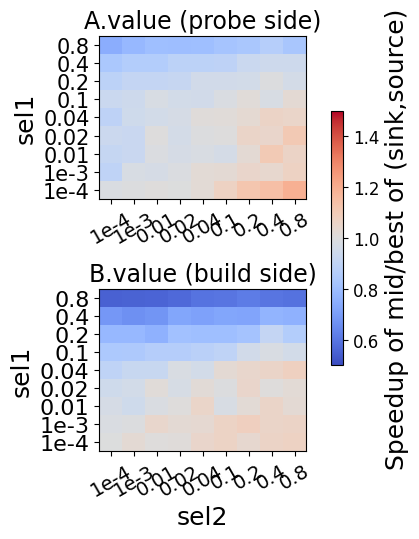

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns


payload_10_data = grouped_data_case1[grouped_data_case1["payload"] == 10]

mat_strat_2 = payload_10_data[(payload_10_data["mat_strat"] == 2)& (payload_10_data["mid_pipe"] == 1)]
mat_strat_0 = payload_10_data[(payload_10_data["mat_strat"] == 1) & (payload_10_data["mid_pipe"] == 0)]

merged_data = pd.merge(
    mat_strat_2, mat_strat_0, on=["sel1", "sel2"], suffixes=("_2", "_0")
)
merged_data["speedup"] = merged_data["latency_0"]/ merged_data["latency_2"] 

sel1_values = sorted(merged_data["sel1"].unique())
sel2_values = sorted(merged_data["sel2"].unique())

sel1_labels = ["1e-4","1e-3","0.01","0.02","0.04","0.1","0.2","0.4","0.8"]
sel2_labels = ["1e-4","1e-3","0.01","0.02","0.04","0.1","0.2","0.4","0.8"]


num_plots = 2
num_cols = 1
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(3.3, 5.5))
hit_ratio = [1]
for idx, hit in enumerate(hit_ratio):
    row = idx // num_cols
    col = idx % num_cols
    ax =  axes[col]
    # only fixed length string 
    group_df = grouped_data_case1

    payload_10_data = group_df[group_df["payload"] == 10]



    mat_strat_2 = payload_10_data[(payload_10_data["mat_strat"] == 2)& (payload_10_data["mid_pipe"] == 1)]
    mat_strat_0 = payload_10_data[(payload_10_data["mat_strat"] == 1) & (payload_10_data["mid_pipe"] == 0)]
    mat_strat_1 = payload_10_data[(payload_10_data["mat_strat"] == 0) & (payload_10_data["mid_pipe"] == 0)]


    merged = pd.merge(
        mat_strat_0,
        mat_strat_1,
        on=["sel1", "sel2", "payload", "mid_pipe"],  
        suffixes=("_0", "_1")
    )
    

    merged["latency"] = merged[["latency_0", "latency_1"]].min(axis=1)

    mat_strat_0 = merged[["sel1", "sel2", "payload", "mid_pipe", "latency"]]
    # mat_strat_0 = payload_10_data[(payload_10_data["mat_strat"] == 0) & (payload_10_data["mid_pipe"] == 0)]
    
    
    merged_data = pd.merge(
        mat_strat_2, mat_strat_0, on=["sel1", "sel2"], suffixes=("_2", "_0")
    )
    merged_data["speedup"] = merged_data["latency_0"]/ merged_data["latency_2"] 
    
    sel1_values = sorted(merged_data["sel1"].unique())
    sel2_values = sorted(merged_data["sel2"].unique())
    color_matrix = np.zeros((len(sel1_values), len(sel2_values)))

    for i, sel1 in enumerate(sel1_values):
        for j, sel2 in enumerate(sel2_values):
            subset = merged_data[(merged_data["sel1"] == sel1) & (merged_data["sel2"] == sel2)]
            if not subset.empty:
                color_matrix[i, j] = subset["speedup"].values[0]

    norm = Normalize(vmin=0.5, vmax=1.5) 
    c = ax.pcolormesh(sel2_labels, sel1_labels, color_matrix, cmap="coolwarm", shading="auto", norm=norm)
    

    ax.set_title("A.value (probe side)", fontsize=17)
    ax.tick_params(axis='x', labelsize=14,rotation=30)
    ax.tick_params(axis='y', labelsize=15)

    if col==0:
        ax.set_ylabel('sel1',fontsize=18)
    # ax.set_xlabel('sel2',fontsize=20)

    
build_hit_ratios = [0.8]
for idx, hit in enumerate(hit_ratio):
    row = idx // num_cols+1
    col = idx % num_cols
    ax =  axes[row]
    # only fixed length string 
    group_df = grouped_data_case2

    payload_10_data = group_df[group_df["payload"] == 10]

    mat_strat_2 = payload_10_data[(payload_10_data["mat_strat"] == 1) & (payload_10_data["add_breaker"] == 1)]
    mat_strat_0 = payload_10_data[(payload_10_data["mat_strat"] == 1) & (payload_10_data["add_breaker"] == 0)]
    mat_strat_1 = payload_10_data[(payload_10_data["mat_strat"] == 0) & (payload_10_data["add_breaker"] == 0)]

    merged = pd.merge(
        mat_strat_0,
        mat_strat_1,
        on=["sel1", "sel2", "payload", "add_breaker"],  
        suffixes=("_0", "_1")
    )
    
    merged["latency"] = merged[["latency_0", "latency_1"]].min(axis=1)
    
    mat_strat_0 = merged[["sel1", "sel2", "payload", "add_breaker", "latency"]]


    merged_data = pd.merge(
        mat_strat_2, mat_strat_0, on=["sel1", "sel2"], suffixes=("_2", "_0")
    )
    merged_data["speedup"] = merged_data["latency_0"]/ merged_data["latency_2"] 
    
    sel1_values = sorted(merged_data["sel1"].unique())
    sel2_values = sorted(merged_data["sel2"].unique())

    color_matrix = np.zeros((len(sel1_values), len(sel2_values)))

    for i, sel1 in enumerate(sel1_values):
        for j, sel2 in enumerate(sel2_values):
            subset = merged_data[(merged_data["sel1"] == sel1) & (merged_data["sel2"] == sel2)]
            if not subset.empty:
                color_matrix[i, j] = subset["speedup"].values[0]

    norm = Normalize(vmin=0.5, vmax=1.5) 
    c = ax.pcolormesh(sel2_labels, sel1_labels, color_matrix, cmap="coolwarm", shading="auto", norm=norm)
    

    ax.set_title("B.value (build side)", fontsize=17)
    ax.tick_params(axis='x', labelsize=14,rotation=30)
    ax.tick_params(axis='y', labelsize=16)
    

    if col==0:
        ax.set_ylabel('sel1',fontsize=18)
    ax.set_xlabel('sel2',fontsize=18)

cbar = fig.colorbar(c, ax=axes[:2], orientation="vertical",anchor=(3,0.7), shrink=0.6)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Speedup of mid/best of (sink,source)", fontsize=18)

plt.subplots_adjust(wspace=0, hspace=-1.9)



for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
plt.tight_layout()
plt.savefig("paper_figure/micro/speedup_heatmap_best_vertical.pdf", bbox_inches="tight")
plt.show()

## Frequency table (Figure 15)

/tmp/ipykernel_2943377/1992649789.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frequency = df.groupby(["sel1_bin", "sel2_bin"]).size().unstack(fill_value=0)


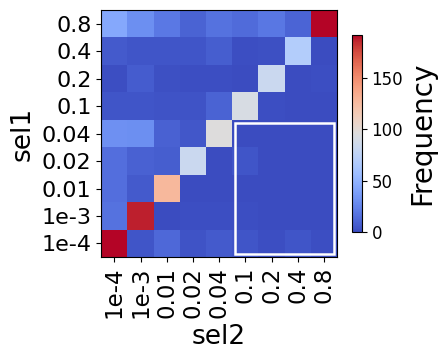

In [137]:
import pandas as pd

def parse_and_count(file_path):

    df = pd.read_csv(file_path, header=None, names=["sel1", "sel2"])

    df = df[df["sel2"] <= 1.1]

    bins = [0, 0.0005, 0.005, 0.015, 0.03, 0.07, 0.15, 0.3, 0.6, 10000.0]
    labels = [
        "[0, 0.0005)", "[0.0005, 0.005)", "[0.005, 0.015)", "[0.015, 0.03)", "[0.03, 0.07)",
        "[0.07, 0.15)", "[0.15, 0.3)", "[0.3, 0.6)", "[0.6, )"
    ]

    df["sel1_bin"] = pd.cut(df["sel1"], bins=bins, labels=labels, right=False)
    df["sel2_bin"] = pd.cut(df["sel2"], bins=bins, labels=labels, right=False)

    frequency = df.groupby(["sel1_bin", "sel2_bin"]).size().unstack(fill_value=0)

    return frequency

file_path = "origin_data/microbench/selectivity.txt"
frequency_table = parse_and_count(file_path)



import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

def plot_heatmap(frequency_table):
    sel1_labels = frequency_table.index.astype(str)
    sel2_labels = frequency_table.columns.astype(str)
    sel1_labels = ["1e-4","1e-3","0.01","0.02","0.04","0.1","0.2","0.4","0.8"]
    sel2_labels = ["1e-4","1e-3","0.01","0.02","0.04","0.1","0.2","0.4","0.8"]
    color_matrix = frequency_table.values

    norm = Normalize(vmin=color_matrix.min(), vmax=color_matrix.max()-300)
    norm = Normalize(vmin=color_matrix.min(), vmax=color_matrix.max()-200)
    fig, ax = plt.subplots(figsize=(4.5, 3.7))
    c = ax.pcolormesh(sel2_labels, sel1_labels, color_matrix, cmap="coolwarm", shading="auto", norm=norm)

    # fig.colorbar(c, ax=ax)

    ax.set_xlabel("sel2", fontsize=19)
    ax.set_ylabel("sel1", fontsize=19)
    # ax.set_title("frequency table", fontsize=19)
    
    cbar = fig.colorbar(c, ax=ax, orientation="vertical", shrink=0.8)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label("Frequency", fontsize=20)
    ax.tick_params(axis='x', labelsize=16.5,rotation=90)
    ax.tick_params(axis='y', labelsize=16)

    i_start, i_end = 0, 3 
    j_start, j_end = 5, 7 
    
    xmin = j_start-0.4
    xmax = j_end + 1.4
    ymin = i_start-0.4
    ymax = i_end + 1.4
    
   
    rect = plt.Rectangle(
        (xmin, ymin),      
        xmax - xmin,     
        ymax - ymin,     
        linewidth=1.8,
        edgecolor='white',
        facecolor='none',
        zorder=10          
    )
    ax.add_patch(rect)      
        

    plt.tight_layout()
    plt.savefig("paper_figure/micro/freq_table.pdf", bbox_inches="tight")
    plt.show()

plot_heatmap(frequency_table)


# stddev of different row groups (Figure 16)

In [138]:
import re
import matplotlib.pyplot as plt

def parse_stddev(file_path):
    stddev_list = []
    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(r"Standard deviation of counts: ([0-9.]+)", line)
            if match:
                stddev_list.append(float(match.group(1)))
    return stddev_list

def plot_histogram(stddev_list):
    plt.figure(figsize=(10, 6))
    plt.hist(stddev_list, bins=30, color='skyblue', edgecolor='black')
    plt.title("Histogram of Standard Deviations")
    plt.xlabel("Standard Deviation")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

file_path = "origin_data/microbench/job_variance.txt"
stddev_list = parse_stddev(file_path)

file_path = "origin_data/microbench/tpcds_variance.txt"
stddev_list = parse_stddev(file_path) + stddev_list

# plot_histogram(stddev_list)

In [140]:
import pandas as pd
import numpy as np

columns = [
    "compressed", "probe_side", "build_side", "sel", "payload", "dist",
    "cluster_hit_ratio", "build_dis", "probe_dis", "mat_strat", "queue_thr","zipf_factor",
    "materialize_times", "single_time_avg_rows", "total_materialized_chunks",
    "total_materialized_rows", "map_building_time", "mat_operator_time"
]

data = []
with open('origin_data/microbench/payload_build_time_0508.txt', 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 2):

        
        values = lines[i].strip().split()
        # print(lines[i])
        try:
            values = [int(values[0]), int(values[1]), int(values[2]), float(values[3]), int(values[4]),
                  values[5], float(values[6]), values[7], values[8], int(values[9]), int(values[10]), float(values[11])]
        
            additional_values = lines[i + 1].strip().split()
            additional_values = [int(additional_values[0]), float(additional_values[1]), int(additional_values[2]),
                             int(additional_values[3]), float(additional_values[4]), float(additional_values[5])]
            values.extend(additional_values)
            data.append(values)
        except:

            continue


df = pd.DataFrame(data, columns=columns)
# df = df[df['payload']!=20]


uniform_data = df[df['dist'] == 'uniform']

results = []

for sel in df['sel'].unique():
    uniform_latency = uniform_data[uniform_data['sel'] == sel]['mat_operator_time'].mean()

 
    sel_data = df[df['sel'] == sel]

    for zipf_factor in sel_data['zipf_factor'].unique():
        zipf_latency = sel_data[sel_data['zipf_factor'] == zipf_factor]['mat_operator_time'].mean()

        latency_diff = abs((zipf_latency - uniform_latency)/uniform_latency)

        results.append({
            'selectivity': sel,
            'zipf_factor': zipf_factor,
            'latency_diff': latency_diff
        })


result_df = pd.DataFrame(results)
grouped_result = result_df.groupby(['zipf_factor'])['latency_diff'].mean().reset_index()


grouped_result.columns = ['zipf_factor', 'avg_latency_diff']


grouped_result = grouped_result[(grouped_result['zipf_factor']!=1.0001)&(grouped_result['zipf_factor']!=1.0009)]
grouped_result

,zipf_factor,avg_latency_diff
0,1.00,0.000000
3,1.01,0.008955
4,1.05,0.016791
5,1.10,0.035686
6,1.20,0.051574
7,1.30,0.063692
8,1.40,0.066111
9,1.50,0.094315
10,1.60,0.126022
11,1.70,0.158570


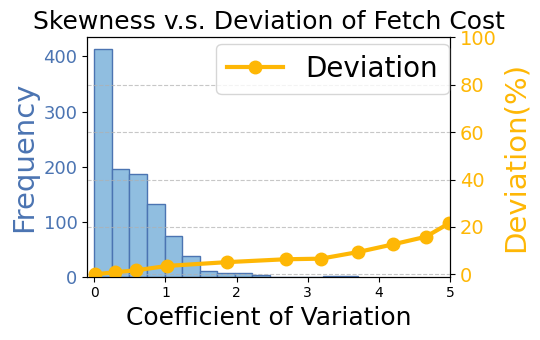

In [141]:
import matplotlib.pyplot as plt
import numpy as np

color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
bins = np.linspace(min(stddev_list), max(stddev_list), 100)  # 分箱
freq, edges = np.histogram(stddev_list, bins=bins)


bin_centers = (edges[:-1] + edges[1:]) / 2

fig, ax1 = plt.subplots(figsize=(5.5, 3.5))

ax1.hist(stddev_list, bins=15, color=color_map[1], edgecolor=color_map[0])
ax1.set_xlabel('Coefficient of Variation', fontsize=18)
ax1.set_ylabel('Frequency', fontsize=21, color=color_map[0])
ax1.tick_params(axis='y', labelcolor=color_map[0], labelsize=13)

dev = [0.00888875479526797, 0.2862245675671749, 0.5814835360584508, 1.0266156099498267,1.8689935820693004, 2.692395320785051, 3.1855255394191624,3.712037103614017,4.193649179491293, 4.6621686948657395,4.991006804480685,5.380939731444071]
ax2 = ax1.twinx()
ax2.plot(dev, 100*grouped_result['avg_latency_diff'], color=line_color[2], marker='o', label='Deviation',ms=9,linewidth=3)
ax2.set_ylabel('Deviation(%)', fontsize=21, color=line_color[2])
ax2.tick_params(axis='y', labelsize=14,labelcolor=line_color[2])

ax2.set_ylim([-1,100])

plt.xlim([-0.1,5])
# plt.xticks(fontsize=25)
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.9), fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.title('Skewness v.s. Deviation of Fetch Cost', fontsize=18)

plt.tight_layout()
plt.savefig("paper_figure/micro/skew_dev.pdf", bbox_inches="tight")
plt.show()

## Optimization overhead

In [149]:
import os
import pandas as pd

def parse_overhead_files(directory):

    files = [f for f in os.listdir(directory) if f.endswith('_overhead_0510.txt')]
    results = []

    for file in files:
        file_path = os.path.join(directory, file)

        try:
            df = pd.read_csv(file_path, header=None, names=['search_time', 'optimize_time', 'total_latency', 'percentage'])
    

            min_row = df.loc[df['total_latency'].idxmin()]
            min_row['file'] = file.split('_')[0]
            results.append(min_row)
        except:
            continue

    result_df = pd.DataFrame(results)

    return result_df

directory = 'origin_data/job_result/'
result_df = parse_overhead_files(directory)

result_df

,search_time,optimize_time,total_latency,percentage,file
1,0.84,0.57,715.55,0.54,19a
0,1.00,0.49,112.29,3.43,33a
1,0.32,0.64,535.17,0.64,5a
0,0.74,0.50,261.93,1.41,14c
1,0.43,0.43,608.63,0.55,31c
0,0.80,0.42,143.11,2.53,27b
1,1.00,0.64,1072.86,0.39,29c
0,0.98,0.57,709.75,0.57,28b
0,0.29,0.63,121.50,2.74,2a
0,0.37,0.55,271.21,1.25,16a


In [150]:
import numpy as np
ar = np.array(result_df['percentage'])
print(min(ar),max(ar),sum(ar)/len(ar))

0.39 15.11 2.121515151515151


In [151]:
ar = np.array(result_df['search_time'])+np.array(result_df['optimize_time'])+2.5
print(min(ar),max(ar),sum(ar)/len(ar))

3.27 4.140000000000001 3.610606060606061
